**Goal:** hide the species labels and let k-means rediscover the three penguin
groups from four measurements alone -- then choose the number of clusters
honestly, see them on L20's PCA picture, flag the outliers by distance, and
compare against hierarchical clustering. Pairs with the concept note
[Finding Groups & Outliers](l21_concept_clustering_outliers.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u05_visualization/l21_lab_penguins_clustering.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l21_lab_penguins_clustering.ipynb`) -- in Colab via the badge above, or
> locally. Every text output below comes from actually running the cells.

## Prerequisites & Setup

The same **Palmer Penguins** as L20 (CC0 public domain). k-means starts from a
random seed, so we fix `random_state=0` for reproducibility -- everyone sees
identical clusters.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + load + standardize (clustering needs scaled features)
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

PENGUINS_LOCAL = "data/penguins.csv"
PENGUINS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
if not os.path.exists(PENGUINS_LOCAL):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(PENGUINS_URL, PENGUINS_LOCAL)

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
clean = pd.read_csv(PENGUINS_LOCAL).dropna(subset=features).reset_index(drop=True)
X = StandardScaler().fit_transform(clean[features])   # standardize: distances are unit-sensitive
print("Clean penguins:", X.shape)

Clean penguins: (342, 4)


<details><summary>Expected Output</summary>

~~~text
Clean penguins: (342, 4)
~~~
</details>

> **Read it:** 342 penguins, 4 standardized features, and -- crucially -- we
> will NOT pass the species column to the algorithm. It clusters on the
> measurements alone; the species is the answer key we check against at the
> end.

## Step 1: k-means Finds Three Groups (Worked)

Run k-means for k=3. It drops three centroids, assigns each penguin to the
nearest one (an L18 distance), moves the centroids to the mean of their
points, and repeats. Then we grade it against the hidden species:

In [3]:
km = KMeans(n_clusters=3, random_state=0, n_init=10).fit(X)
clean["cluster"] = km.labels_

print(f"Inertia: {km.inertia_:.1f}")
print(f"Silhouette score: {silhouette_score(X, km.labels_):.3f}")
print("Cluster vs species:")
ct = pd.crosstab(clean["cluster"], clean["species"])
print(ct)
agree = ct.max(axis=1).sum()
print(f"Majority-species agreement: {agree}/{len(clean)} = {agree/len(clean):.1%}")

Inertia: 379.4
Silhouette score: 0.447
Cluster vs species:
species  Adelie  Chinstrap  Gentoo
cluster                           
0             0          0     123
1           127          5       0
2            24         63       0
Majority-species agreement: 313/342 = 91.5%


<details><summary>Expected Output</summary>

~~~text
Inertia: 379.4
Silhouette score: 0.447
Cluster vs species:
species  Adelie  Chinstrap  Gentoo
cluster                           
0             0          0     123
1           127          5       0
2            24         63       0
Majority-species agreement: 313/342 = 91.5%
~~~
</details>

> **Read it:** with no labels, k-means recovers the species **91.5%** of the
> time. Cluster 0 is 123 pure Gentoo; cluster 1 is almost all Adelie; cluster
> 2 is mostly Chinstrap but with 24 Adelie mixed in -- exactly the
> Adelie/Chinstrap overlap L20 showed. The crosstab is how you grade a
> clustering *when you happen to have labels*; usually you do not, which is
> the whole reason to cluster.

## Step 2: How Many Clusters? (Worked + Completion)

We told it k=3, but how would we know? Two guides. First the **elbow**: inertia
always falls as k grows, but the improvement flattens at a "knee". Then the
**silhouette**: how cleanly separated the clusters are (higher is better).

In [4]:
print("Elbow -- inertia by k:")
for k in range(1, 7):
    print(f"k={k}: inertia={KMeans(n_clusters=k, random_state=0, n_init=10).fit(X).inertia_:.0f}")
print()
print("Silhouette by k:")
for k in range(2, 7):
    s = silhouette_score(X, KMeans(n_clusters=k, random_state=0, n_init=10).fit(X).labels_)
    print(f"k={k}: silhouette={s:.3f}")

Elbow -- inertia by k:
k=1: inertia=1368
k=2: inertia=566
k=3: inertia=379
k=4: inertia=300
k=5: inertia=233
k=6: inertia=204

Silhouette by k:
k=2: silhouette=0.532
k=3: silhouette=0.447
k=4: silhouette=0.400
k=5: silhouette=0.378
k=6: silhouette=0.372


<details><summary>Expected Output</summary>

~~~text
Elbow -- inertia by k:
k=1: inertia=1368
k=2: inertia=566
k=3: inertia=379
k=4: inertia=300
k=5: inertia=233
k=6: inertia=204
Silhouette by k:
k=2: silhouette=0.532
k=3: silhouette=0.447
k=4: silhouette=0.400
k=5: silhouette=0.378
k=6: silhouette=0.372
~~~
</details>

> **Read it:** the inertia drops steeply to k=3 then flattens -- the elbow
> points at **3**. But the silhouette is *highest at k=2* (0.532): the single
> cleanest split is Gentoo vs everyone else, because Adelie and Chinstrap
> overlap and separating them lowers the score. The two guides disagree, and
> that is normal: **k is a judgment.** Domain knowledge (three species) and
> what you will do with the groups break the tie -- not the metric alone.

Your turn -- read one silhouette value directly:

In [5]:
# Uncomment and fill the ____ : fit k-means with n_clusters=4 and score it.
# km4 = KMeans(n_clusters=____, random_state=0, n_init=10).fit(X)
# print(f"silhouette(k=4) = {silhouette_score(X, km4.labels_):.3f}")

<details><summary>Expected Output</summary>

~~~text
silhouette(k=4) = 0.400
~~~
*(Splitting into 4 is worse-separated than 3 and far worse than 2 -- adding
clusters past the real structure just carves real groups into arbitrary
pieces.)*
</details>

## Step 3: See the Clusters on L20's Projection (Worked)

Clustering pairs with L20's PCA: project to 2D, then color the same scatter two
ways -- by the cluster k-means assigned (no labels) and by the true species
(the answer key). If they match, the algorithm found the biology.

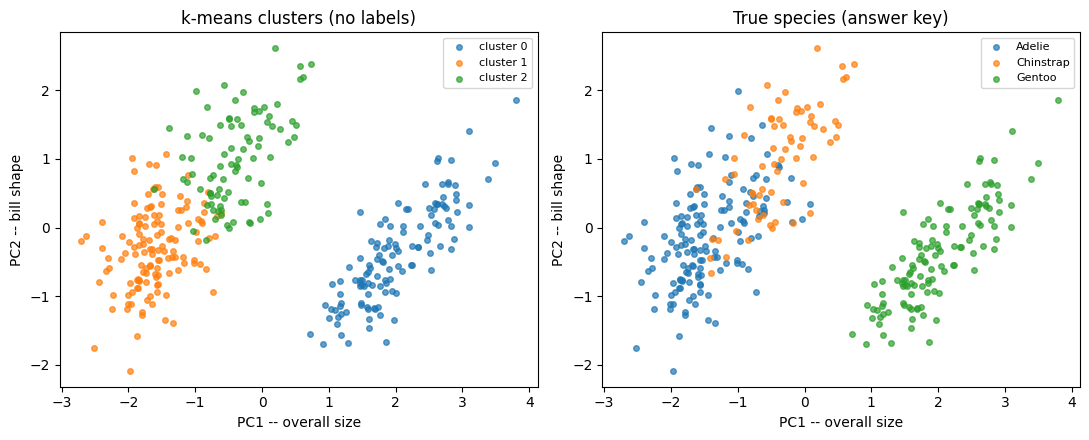

In [6]:
scores = PCA(n_components=2).fit_transform(X)
clean["PC1"], clean["PC2"] = scores[:, 0], scores[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for c in sorted(clean["cluster"].unique()):
    m = clean["cluster"] == c
    axes[0].scatter(clean.loc[m, "PC1"], clean.loc[m, "PC2"], s=16, alpha=0.7, label=f"cluster {c}")
axes[0].set_title("k-means clusters (no labels)")
axes[0].legend(fontsize=8)
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    m = clean["species"] == sp
    axes[1].scatter(clean.loc[m, "PC1"], clean.loc[m, "PC2"], s=16, alpha=0.7, label=sp)
axes[1].set_title("True species (answer key)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("PC1 -- overall size"); ax.set_ylabel("PC2 -- bill shape")
plt.tight_layout()
plt.show()

> **Read it:** the two panels line up. The tight Gentoo group on the right is
> recovered exactly; the Adelie/Chinstrap pair on the left is split along the
> seam where they overlap -- the same 8.5% the crosstab counted. PCA gave us
> the picture (L20); k-means gave us the *assignment* (which bird in which
> group). Together they turn four measurements into discovered groups.

## Step 4: Outliers by Distance (Worked + Completion)

The distances that built the clusters also flag the **outliers**: each point's
distance to *its own* centroid says how typical it is. The farthest points are
the anomalies to inspect.

In [7]:
centroids = km.cluster_centers_
clean["dist_to_centroid"] = np.linalg.norm(X - centroids[km.labels_], axis=1)   # L18 distance

outlier = clean.loc[clean["dist_to_centroid"].idxmax()]
print(f"Most atypical: {outlier['species']} on {outlier['island']}, "
      f"distance {outlier['dist_to_centroid']:.2f}")
print(outlier[features])

Most atypical: Gentoo on Biscoe, distance 2.88
bill_length_mm         59.6
bill_depth_mm          17.0
flipper_length_mm     230.0
body_mass_g          6050.0
Name: 252, dtype: object


<details><summary>Expected Output</summary>

~~~text
Most atypical: Gentoo on Biscoe, distance 2.88
bill_length_mm         59.6
bill_depth_mm          17.0
flipper_length_mm     230.0
body_mass_g          6050.0
Name: 252, dtype: object
~~~
</details>

> **Read it:** the same giant Gentoo L20 circled in its projection -- the
> longest bill in the dataset, near-record flipper and mass. Far from its
> centroid means "unusual even for its own group". Not an error, just a very
> large penguin -- but distance is how you find the rows worth a second look.

Your turn -- list the three most atypical penguins:

In [8]:
# Uncomment and fill the ____ : nlargest(n, column) returns the n biggest rows.
# top3 = clean.nlargest(____, "dist_to_centroid")[["species", "island", "dist_to_centroid"]]
# print(top3.round(2).to_string(index=False))

<details><summary>Expected Output</summary>

~~~text
  species island  dist_to_centroid
   Gentoo Biscoe              2.88
Chinstrap  Dream              2.30
   Gentoo Biscoe              2.11
~~~
*(Two outsized Gentoo and one unusual Chinstrap -- the points an analyst would
inspect before trusting any model fit on this data.)*
</details>

## Step 5: Another Way -- Hierarchical Clustering (Worked)

k-means needs k up front. **Hierarchical** clustering instead merges the two
nearest groups over and over, recording the whole tree as a **dendrogram** you
can cut at any height:

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X, method="ward")
clean["hier"] = fcluster(Z, t=3, criterion="maxclust")   # cut the tree into 3 groups

cth = pd.crosstab(clean["hier"], clean["species"])
print(cth)
ah = cth.max(axis=1).sum()
print(f"Hierarchical agreement: {ah}/{len(clean)} = {ah/len(clean):.1%}")

species  Adelie  Chinstrap  Gentoo
hier                              
1             0          0     123
2             0         57       0
3           151         11       0
Hierarchical agreement: 331/342 = 96.8%


<details><summary>Expected Output</summary>

~~~text
species  Adelie  Chinstrap  Gentoo
hier                              
1             0          0     123
2             0         57       0
3           151         11       0
Hierarchical agreement: 331/342 = 96.8%
~~~
</details>

> **Read it:** a completely different algorithm, the same biology -- and here
> a touch cleaner, **96.8%** agreement (it splits Gentoo and Chinstrap nearly
> perfectly). Hierarchical never asked us for k; we got it by cutting the tree
> at three branches. Prefer it when you do not want to commit to k in advance
> or when nested structure matters; prefer k-means when the data is large and
> you have a k in mind.

## Your Turn (Exercises)

### Exercise 1 -- Which k would you report?

Re-run k-means at k=2 and k=4. For each, print the silhouette and the
cluster-vs-species crosstab. In 2-3 sentences: which k would you report for
this dataset, and why -- given that the silhouette prefers 2 but you know there
are three species?

> **Hint:** reuse Step 1's pattern with `n_clusters=2` then `=4`; the
> silhouette and crosstab calls are the same.

In [10]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
k=2: silhouette 0.532  (Gentoo alone vs Adelie+Chinstrap together)
k=4: silhouette 0.400  (one real species gets split in two)
~~~
*(k=2 scores best but merges two real species; k=4 splits a real one. k=3 is
the defensible report: it matches the known biology and sits at the inertia
elbow, even though k=2's silhouette is higher. State that reasoning -- "the
metric preferred 2, but domain knowledge and the elbow support 3".)*
</details>

### Exercise 2 -- The oddball in each cluster

For each of the three k-means clusters, find its single most atypical member
(largest distance to that cluster's centroid) and print the species, island,
and distance. One sentence on whether the oddballs are the same species as
their cluster's majority.

> **Hint:** you already have `dist_to_centroid` and `cluster`; group by
> `cluster` and take `idxmax()` of the distance, or sort within each group.

In [11]:
# TODO: your code here

<details><summary>Expected Output (one possible answer -- match the values, not the print format)</summary>

~~~text
cluster 0: Gentoo on Biscoe, distance 2.88
cluster 1: Adelie on Torgersen, distance 2.06
cluster 2: Chinstrap on Dream, distance 2.30
~~~
*(Each cluster's oddball is usually a member of that cluster's majority species
that happens to be extreme on the measurements -- a within-group anomaly, not a
mislabeled bird. With `random_state=0` these distances are exact.)*
</details>

### Exercise 3 -- Written: clustering with no answer key

A marketing team hands you a table of 10,000 customers (spend, visits, age,
tenure, ...) with NO segment labels and asks you to "find the customer types".
In 3-4 sentences: what can clustering tell them and what can it not, how would
you choose k, and name one concrete risk of presenting the clusters as
"the customer segments".

> **Hint:** remember the penguins had a hidden answer key to check against --
> the marketing table does not. What does that change? And recall the pitfall
> that clustering *always* returns groups.

## Summary

| Move | Key commands | What you learned |
|------|-------------|------------------|
| Standardize, then cluster | `StandardScaler` + `KMeans(n_clusters=k, random_state=0)` | k-means assigns each point to its nearest centroid |
| Grade it (if labels exist) | `pd.crosstab`, `silhouette_score` | 91.5% species agreement, unsupervised |
| Choose k | inertia elbow + silhouette | They can disagree (elbow 3, silhouette 2) -- k is a judgment |
| See the groups | color the L20 PCA scatter by cluster | Clustering assigns; PCA shows |
| Find outliers | `np.linalg.norm(X - centroids[labels])` | Distance to centroid = how atypical (the giant Gentoo) |
| Another method | `linkage(X, "ward")` + `fcluster` | Hierarchical: cut a dendrogram, no k up front (96.8%) |

This closes **Unit V -- Visualization**: space (L16), time (L17), the
linear-algebra primer (L18), correlation (L19), PCA (L20), and now groups and
outliers. Next unit: recommender systems.